In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import numpy as np
np.float = np.float64

import healpy as hp
import jax.numpy as jnp

sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")
sys.path.append("/n/home07/yitians/fermi/NPTFit")
from NPTFit import npll

sys.path.append("../nptfit")
from nptfit_func import *

sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

## templates and masks

In [2]:
nside = 128
band_mask_range = 2.
r_outer = 25.

# mask
mask_plane = cm.make_mask_total(
    nside=nside,
    band_mask=True,
    band_mask_range=band_mask_range,
    mask_ring=True,
    inner=0,
    outer=r_outer,
)
m = normalization_mask = mask_plane

# templates
nfw_template = NFWTemplate(nside=nside)
disk_template = LorimerDiskTemplate(nside=nside)
temp_dict = {
    'gce' : nfw_template.get_NFW2_template(gamma=0.9),
    'dsk' : disk_template.get_template(zs=0.5, C=2.5),
}
for k in temp_dict.keys():
    temp_dict[k] /= np.mean(temp_dict[k][~m])

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## truth

In [3]:
vd_base = dict(
    Sps_dsk = None,
    Sps_gce = None,
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
)

## scan LL

In [4]:
def dnds(s, theta):
    a, n1, n2, n3, sb1, sb2 = theta
    dnds = a * (sb2/sb1)**-n2 * np.where(
        s<sb2,
        (s/sb2)**-n3,
        np.where(
            (s >= sb2) * (s < sb1),
            (s/sb2)**-n2,
            (sb1/sb2)**-n2 * (s/sb1)**-n1
        )
    )
    return dnds

In [5]:
from nptfit_func import *

In [8]:
#psf_name = 'king'
psf_name = 'delta'
if psf_name == 'king':
    kp = KingPSF()
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = kp.psf_fermi_r, num_f_bins=30)
elif psf_name == 'delta' or psf_name == 'true_delta':
    sigma = np.deg2rad(0.001) / 3
    psf_r_func = lambda r: np.exp(-0.5 * (r / sigma) ** 2) / (2 * np.pi * sigma ** 2)
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = psf_r_func, num_f_bins=30)

if psf_name == 'true_delta':
    df_rho_div_f_ary *= 0.
    df_rho_div_f_ary[-1] = 1./(f_ary[-1]**2)

print(np.sum(df_rho_div_f_ary*f_ary**2))

df = f_ary[1] - f_ary[0]
plot = False
if plot:
    plt.plot(f_ary, df_rho_div_f_ary/df*f_ary**2)
    plt.fill_between(f_ary, df_rho_div_f_ary/df*f_ary**2, 0., alpha=0.5)
    plt.ylabel(r'$f\cdot\rho(f)$')
    plt.xlabel(r'$f$');

1.0


In [7]:
include_temps = ['gce', 'dsk']

temps = [temp_dict[k][~m] for k in include_temps]

In [9]:
data_dir = "Sps_dsk_gce_verydeltapsf"

In [11]:
vd = pickle.load(open(f'{data_dir}/truth.p', 'rb'))

# S over A
Sps_over_A_dict = {}
for i, k in enumerate(include_temps):
    s_ary = np.logspace(-1., 2., 1000)
    theta_tmp = np.array([1., vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['lambdas_'+k] * vd['sb1_'+k]])
    dnds_ary = dnds(s_ary, theta_tmp)
    Sps_over_A_dict[k] = np.mean(temps[i]) * np.trapz(s_ary * dnds_ary, s_ary)
    print(k, Sps_over_A_dict[k])

gce 72.96652
dsk 130.7289


In [10]:
include_temps

['gce', 'dsk']

In [16]:
#ll_func = log_like
ll_func = npll.log_like
Sps_key = 'dsk'
vk = vd['Sps_'+Sps_key]
Sps_s = np.linspace(0.5*vk, 1.5*vk, 50)
save_fn = f'{data_dir}/ll_ss.p'
include_ps_k = include_temps

ll_ss = []
counts_arr = []
pt_sum_compressed = np.full_like(temps[0], 1e-10, dtype=np.float64)
npt_compressed = [np.array(temps[i], dtype=np.float64) for i in range(len(temps))]

mod_sim = False
if mod_sim:
    data_s = np.array(np.load(f'{data_dir}/data_s.npy'), dtype=np.int32)

for i_data in tqdm(range(50)):
    ll_s = []
    if mod_sim:
        fermi_data = data_s[i_data]#[~m]
    else:
        fermi_data = np.load(f'{data_dir}/counts_{i_data}.npy')[~m].astype(np.int32)
    counts_arr.append(np.sum(fermi_data))
    for i, Sps in enumerate(Sps_s):
        A = {}
        for k in include_ps_k:
            A[k] = vd['Sps_'+k] / Sps_over_A_dict[k]
        A[Sps_key] = Sps / Sps_over_A_dict[k]
        theta = np.array([ [A[k], vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['sb1_'+k]*vd['lambdas_'+k]] for k in include_ps_k ], dtype=np.float64)
        ll = ll_func(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed, fermi_data)
        ll_s.append(ll)
    ll_ss.append(ll_s)
#pickle.dump(ll_ss, open(save_fn, 'wb'))

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [04:27<00:00,  5.35s/it]


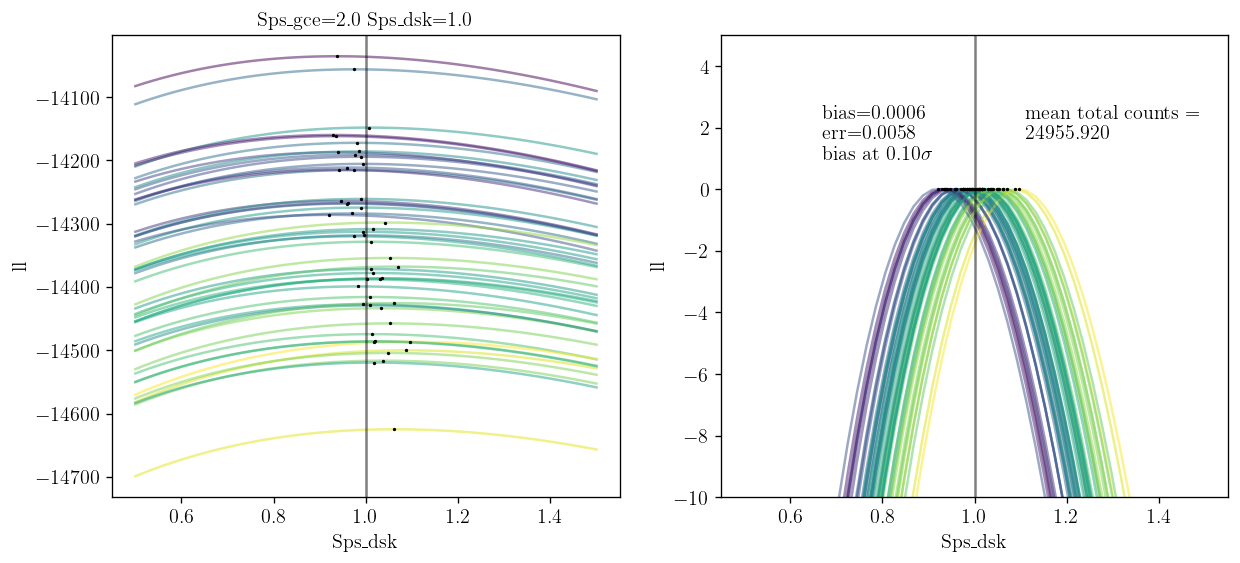

In [17]:
ll_ss = np.array(ll_ss).astype(np.float64)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

max_x_s = []
max_y_s = []

for i in range(50):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    rll = ll_ss[i]
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

    ax = axs[1]
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)

title_str = " ".join([f"Sps_{k}={vd['Sps_'+k]}" for k in include_temps])

ax = axs[0]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(title=title_str, xlabel="Sps_"+Sps_key, ylabel='ll')

ax = axs[1]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(ylim=(-10, 5))
ax.set(xlabel="Sps_"+Sps_key, ylabel='ll')

bias = (np.mean(max_x_s) - vd['Sps_'+Sps_key])
err = np.std(max_x_s) / np.sqrt(len(max_x_s))
bias_sigma = bias/err

ax.text(0.2, 0.85, f"bias={bias:.4f}\nerr={err:.4f}\nbias at {bias_sigma:.2f}"+r"$\sigma$", transform=ax.transAxes, va='top')
ax.text(0.6, 0.85, f"mean total counts = \n{np.mean(counts_arr):.3f}", transform=ax.transAxes, va='top')
fig.savefig('ll.png', dpi = 150)

## view

In [ ]:
def cartplot(z, m, ax=None, title=None, min=1e-1, **kwargs):
    if ax is not None:
        plt.sca(ax)
    hold = (ax is not None)
    zshow = np.zeros_like(m)
    zshow[~m] = z[~m]
    hp.cartview(z, latra=[-25,25], lonra=[-25,25], hold=hold, title=title, norm='log', min=min, **kwargs)

In [ ]:
# data_s old
data_s_old = []
data_dir_old = "../outputs/ll_issue/Sps_dsk_gce_nopscmask_verydeltapsf" # original
for i in tqdm(range(50)):
    data_s_old.append(np.load(f'{data_dir_old}/counts_{i}.npy').astype(np.int32))

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 397.91it/s]


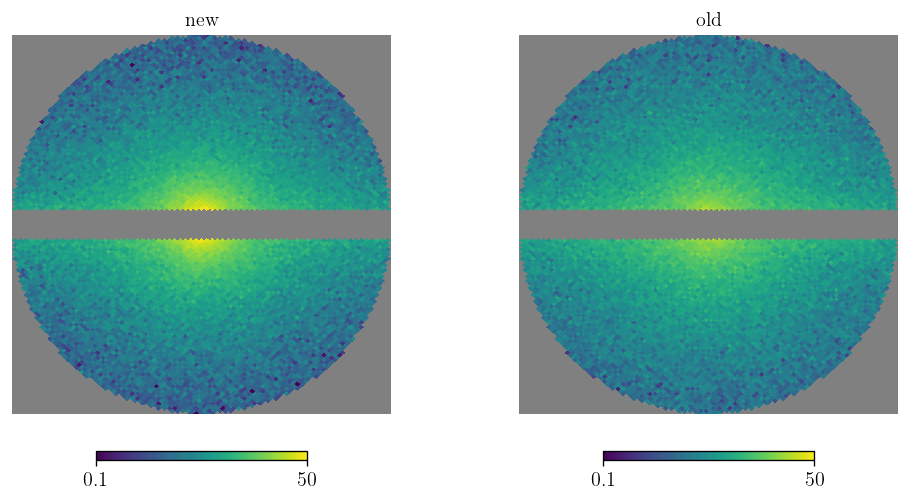

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
kwargs = dict(max=50)
cartplot(np.mean(data_s, axis=0), m, ax=axs[0], title='new', **kwargs)
cartplot(np.mean(data_s_old, axis=0), m, ax=axs[1], title='old', **kwargs)